In [234]:
import cv2
import pytesseract
from matplotlib import pyplot as plt
from PIL import Image
import numpy as np
import re


In [235]:
img_path="passport/1.jpg"
img=cv2.imread(img_path)

In [236]:
def display(im_path):
    dpi = 200
    im_data = plt.imread(im_path)

    height, width  = im_data.shape[:2]
    
    # What size does the figure need to be in inches to fit the image?
    figsize = width / float(dpi), height / float(dpi)

    # Create a figure of the right size with one axes that takes up the full figure
    fig = plt.figure(figsize=figsize)
    ax = fig.add_axes([0, 0, 1, 1])

    # Hide spines, ticks, etc.
    ax.axis('off')

    # Display the image.
    ax.imshow(im_data, cmap='gray')

    plt.show()

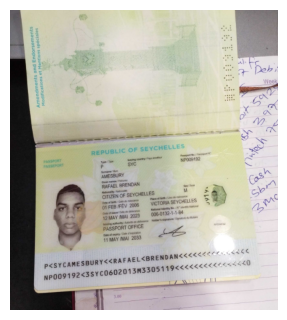

In [237]:
display("passport/9.PNG")

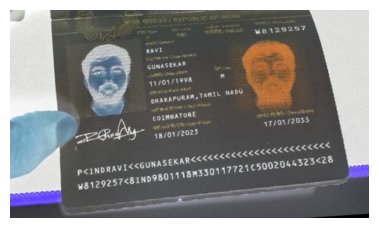

In [238]:
inverted=cv2.bitwise_not(img)
cv2.imwrite("temp_pass/pass_inverted.jpg",inverted)
display("temp_pass/pass_inverted.jpg")

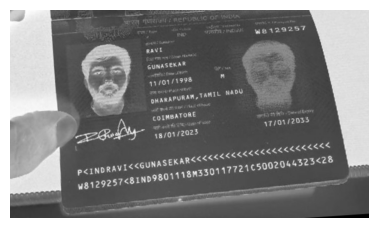

In [239]:
gray=cv2.cvtColor(inverted,cv2.COLOR_BGR2GRAY)
cv2.imwrite("temp_pass/pass_gray.jpg",gray)
display("temp_pass/pass_gray.jpg")

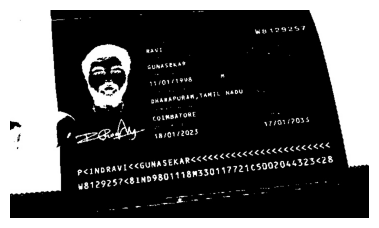

In [240]:
#thresh=cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 15, 10)
thresh=cv2.threshold(gray,0,255,cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]
cv2.imwrite("temp_pass/bw_image.jpg",thresh)
display("temp_pass/bw_image.jpg")

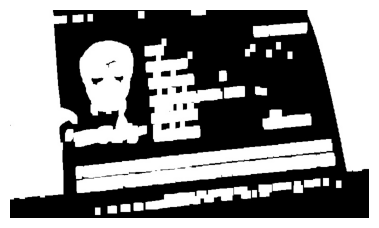

In [241]:
kernel=cv2.getStructuringElement(cv2.MORPH_RECT,(10,15))
dilate=cv2.dilate(thresh,kernel,iterations=1)
cv2.imwrite("temp_pass/pass_dilate.jpg",dilate)
display("temp_pass/pass_dilate.jpg")

83.8597640991211


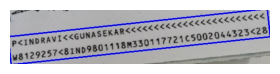

In [242]:
import numpy as np
cnts=cv2.findContours(dilate,cv2.RETR_LIST,cv2.CHAIN_APPROX_SIMPLE)
cnts=cnts[0] if len(cnts)==2 else cnts[1]
base_img=img.copy()
cnts=sorted(cnts,key=lambda x:cv2.boundingRect(x))

for c in cnts:
    x,y,w,h=cv2.boundingRect(c)
    area=cv2.contourArea(c)
    margin=12
   
    if 27000>area>26000:
        rect = cv2.minAreaRect(c)
        box = cv2.boxPoints(rect)
        box = np.intp(box)
        crop=cv2.drawContours(base_img, [box], 0, (255, 0, 0), 2)
        angle=cv2.minAreaRect(c)[-1]
        print(angle)
        #cv2.rectangle(base_img,(x,y),(x+w,y+h),(0,255,0),2)
        roi=base_img[y:y+h,x:x+w]
cv2.imwrite("temp_pass/pass_roi.jpg",roi)
display("temp_pass/pass_roi.jpg")

In [243]:
def rotate(image,angle):
    a=0
    if (angle > 45) :
        a=-(90-angle)
    else:
        a=angle
    r,c=image.shape[:2]
    M=cv2.getRotationMatrix2D(((c-1)/2.0,(r-1)/2.0),a,1)  
    cv2.warpAffine(image,M,(c,r))
    
    return cv2.imwrite("temp_pass/pass_rotated.jpg",image)

In [245]:
ocr_result=pytesseract.image_to_string(roi)
print(ocr_result)

cap
4432328

PCINDRAVI<<6U
reine eey un 3BRSON NITES




In [246]:
import easyocr
import pandas as pd
reader=easyocr.Reader(['en'], gpu=False)
results=reader.readtext(roi)
pd.DataFrame(results,columns=['bbox','text','conf'])

Using CPU. Note: This module is much faster with a GPU.


,bbox,text,conf
0,"[[-1.5218180502855492, 55.06927321394347], [51...",(p<INDRAVI<<GUnASEKAR<<<<<<<<<<<<<<<<<<<<<< <,0.092749
1,"[[1.1535010280253497, 80.12190349528619], [517...",08129257<8IND98011180330117721c5002044323<28,0.622040
